# 🚲 Bike Store Sales Analysis (2016–2017)

This notebook contains the full SQL queries and Python visualisations 
for the Bike Store Sales Analysis project. For project overview, see the [README](./README.md).

Note: Setup codes will be omitted in this notebook.



In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

---

## Section 1: Data Quality Check

Before conducting the analysis, a data quality check was performed to ensure all required tables were loaded correctly. The following query confirms all tables were successfully loaded into the database:

In [108]:
%%sql
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public';

table_name
orders
order_items
products
customers
stores
staffs
stocks
brands
categories


Row counts were verified for the key tables used in this analysis, including orders, order_items, products, stores, staffs and categories:

In [109]:
%%sql
SELECT 'orders' AS table_name, COUNT(*) AS row_count FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'stores', COUNT(*) FROM stores
UNION ALL
SELECT 'categories', COUNT(*) FROM categories
ORDER BY row_count DESC;

table_name,row_count
order_items,4722
orders,1615
products,321
categories,7
stores,3


As the primary objective of this analysis is to examine sales performance across stores, the orders and order_items tables form the foundation of the investigation. The date range and annual order distribution were examined as below to determine the appropriate time period for analysis:

In [110]:
%%sql
SELECT MAX(order_date::date), MIN(order_date::date)
FROM orders

max,min
2018-12-28,2016-01-01


In [111]:
%%sql
SELECT EXTRACT(year FROM order_date::date) AS year, 
       COUNT(*) 
FROM orders 
GROUP BY year 
ORDER BY year;

year,count
2016,635
2017,688
2018,292


To further validate the 2018 data, the monthly order distribution 
across all three years was examined:

In [112]:
%%sql
SELECT EXTRACT(month from order_date::date) AS mth, 
    SUM(CASE WHEN EXTRACT(year from order_date::date) = 2016 THEN 1 ELSE 0 END) AS order_16,
    SUM(CASE WHEN EXTRACT(year from order_date::date) = 2017 THEN 1 ELSE 0 END) AS order_17,
    SUM(CASE WHEN EXTRACT(year from order_date::date) = 2018 THEN 1 ELSE 0 END) AS order_18
FROM orders
GROUP BY EXTRACT(month from order_date::date)
ORDER BY mth

mth,order_16,order_17,order_18
1,50,50,52
2,49,57,35
3,55,67,68
4,43,57,125
5,51,57,0
6,45,63,1
7,50,52,4
8,63,65,2
9,67,53,1
10,64,65,1


**Data Scoping Decision:**

The 2018 data was identified as incomplete. Total orders recorded in 2018 amounted to only 292, significantly lower than the approximately 660 orders per year observed in 2016 and 2017. Further inspection revealed an irregular pattern — order volume rose sharply in April to nearly double the monthly average, followed by a complete drop to zero orders in May, suggesting there might be a data recording issue rather than a business trend.

Therefore, 2018 data was excluded from the analysis. All findings and recommendations presented in this report are based on the period **January 2016 to December 2017**.

---

## Section 2: Macro Sales Trend

To establish a chain-wide overview of sales performance, a 
3-month moving average was calculated across all three stores 
for the period January 2016 to December 2017. A moving average 
was used to smooth out monthly fluctuations and reveal the 
underlying sales trajectory more clearly:

In [113]:
%%sql moving_average <<
WITH monthly_sales_cte AS (
    SELECT DATE_TRUNC('month', order_date::date) AS year_month,
       s.store_name,
       ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric), -3) AS total_sales
    FROM orders AS o
    JOIN order_items AS i ON o.order_id = i.order_id
    JOIN stores AS s ON o.store_id = s.store_id
    WHERE order_date::date >= ' 2016-01-01' AND order_date::date < '2018-01-01'
    GROUP BY s.store_name, DATE_TRUNC('month', order_date::date))

SELECT year_month, store_name, 
    ROUND(AVG(total_sales) OVER(PARTITION BY store_name ORDER BY year_month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 0) AS moving_avg
FROM monthly_sales_cte;

In [114]:
mv_df = moving_average.DataFrame()
mv_df = mv_df.sort_values(['store_name', 'year_month'])

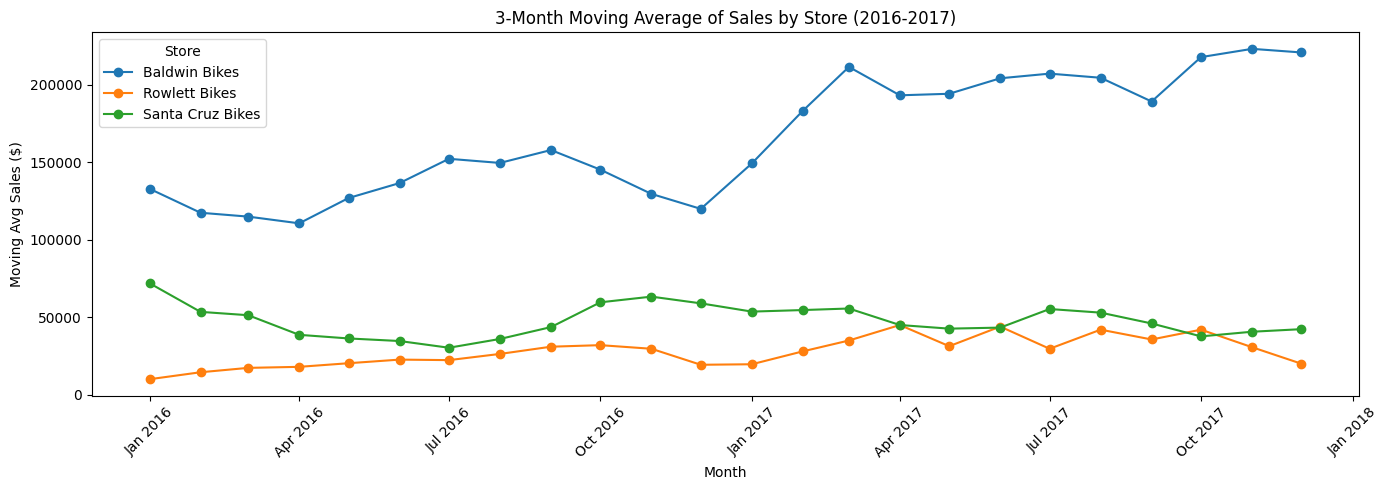

In [115]:
import matplotlib.dates as mdates
plt.figure(figsize=(14, 5))

for store, group in mv_df.groupby('store_name'):
    plt.plot(group['year_month'], group['moving_avg'], marker='o', label=store)

plt.title('3-Month Moving Average of Sales by Store (2016-2017)')
plt.xlabel('Month')
plt.ylabel('Moving Avg Sales ($)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # e.g. "Jan 2017"
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # tick every 3 months
plt.xticks(rotation=45)
plt.legend(title='Store')
plt.tight_layout()
plt.show()

**Findings:**
- **Baldwin Bikes consistently dominates** — generating 3–4x higher 
  revenue than Rowlett and Santa Cruz throughout the entire period
- Baldwin exhibits a **sharp and sustained acceleration in 2017**, 
  diverging significantly from the relatively stable performance 
  of Rowlett and Santa Cruz
- This divergence raises the central question of this analysis: 
  **what drove Baldwin's 2017 growth?**

---

## Section 3: Baldwin Bikes Deep Dive

Having established Baldwin's dominance at the chain level, the 
analysis now focuses specifically on Baldwin Bikes to identify 
when the 2017 growth occurred and how sustained it was. The 
chart below presents Baldwin's monthly revenue for 2016–2017:

In [116]:
%%sql simple_sum <<
SELECT DATE_TRUNC('month', order_date::date) AS year_month,
       ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric), -3) AS total_sales
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
WHERE o.order_date::date >= '2016-01-01' AND o.order_date::date < '2018-01-01' AND s.store_name = 'Baldwin Bikes'
GROUP BY DATE_TRUNC('month', order_date::date)

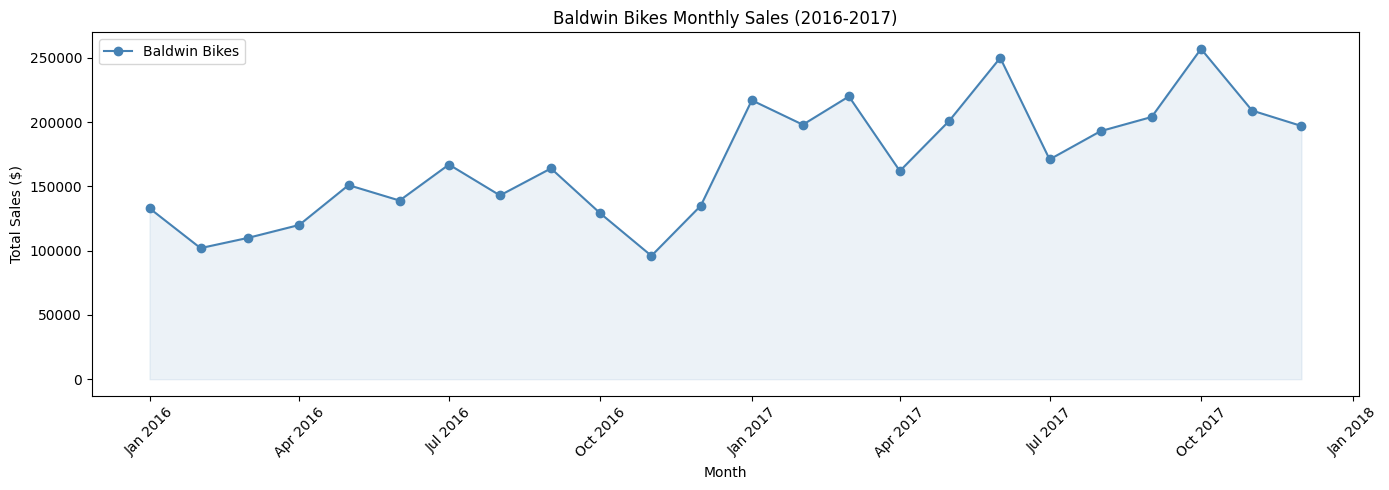

In [117]:
s_df = simple_sum.DataFrame()
ss_df = s_df.sort_values('year_month')

plt.figure(figsize=(14, 5))
plt.plot(ss_df['year_month'], ss_df['total_sales'], marker='o', color='steelblue', label='Baldwin Bikes')
plt.fill_between(ss_df['year_month'], ss_df['total_sales'], alpha=0.1, color='steelblue')  # shading under line

plt.title('Baldwin Bikes Monthly Sales (2016-2017)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

To quantify the overall revenue change between the two years, 
annual totals were compared:

In [118]:
%%sql
SELECT EXTRACT(year from order_date::date) AS year,
       ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric), -3) AS total_sales
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
WHERE o.order_date::date >= '2016-01-01' AND o.order_date::date < '2018-01-01' AND s.store_name = 'Baldwin Bikes'
GROUP BY EXTRACT(year from order_date::date)


year,total_sales
2016,1591000
2017,2480000


**Findings:**

- Baldwin Bikes generated **55.9% more revenue in 2017 than 2016** 
  (total sales: USD 2,480k vs USD 1,591k)
- The revenue surge began at the **start of 2017** and was sustained 
  consistently throughout the year, rather than being concentrated 
  in a single peak month
- The sustained and consistent nature of the growth suggests a 
  **structural change** — such as a new product launch, pricing 
  strategy or market development — rather than a one-off event
- To identify the root cause, the following sections examine 
  price, volume and product category performance in detail

---

## Section 4: Price and Volume Analysis

When revenue increases significantly, the growth can typically 
be attributed to either an increase in average selling price, 
an increase in sales volume, or a combination of both. To 
determine which factor drove Baldwin's 2017 growth, the average 
price per unit and total sales volume were compared between 
2016 and 2017:


In [119]:
%%sql 
SELECT EXTRACT(year from order_date::date)::int AS year,
    ROUND((SUM(i.list_price * (1-i.discount) * i.quantity)::numeric/SUM(i.quantity)), 0) AS avg_price,
    SUM(i.quantity) AS total_volume
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
WHERE s.store_name = 'Baldwin Bikes' 
    AND EXTRACT(year from order_date::date) IN (2016, 2017) 
GROUP BY EXTRACT(year from order_date::date)::int

year,avg_price,total_volume
2016,878,1811
2017,1149,2159


**Findings:**

- **Average price increased by approximately 30%** in 2017 compared 
  to 2016 (USD 878 vs USD 1,149 per unit), suggesting a shift 
  towards higher-value products
- **Total sales volume also increased by approximately 20%** 
  (1,811 vs 2,159 units), indicating stronger overall customer demand
- The simultaneous increase in both price and volume could reflect 
  an **increase in overall store popularity**
- To investigate the underlying cause, the following section 
  examines how product category performance changed between 
  2016 and 2017

---

## Section 5: Category Analysis

To identify if product category drove the simultaneous 
increase in price and volume observed at Baldwin, product 
category performance was compared between 2016 and 2017 
across all three stores, examining order count, revenue 
and average selling price per category.

**Baldwin Bikes:**

In [120]:
%%sql
WITH revenue_base AS (
    SELECT 
        c.category_name,
        EXTRACT(year FROM order_date::date) AS year,
        i.list_price::numeric * (1-i.discount)::numeric AS unit_price,
        i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric AS revenue
    FROM orders AS o
    JOIN order_items AS i ON o.order_id = i.order_id
    JOIN stores AS s ON o.store_id = s.store_id
    JOIN products AS p ON i.product_id = p.product_id
    JOIN categories AS c ON p.category_id = c.category_id
    WHERE s.store_name = 'Baldwin Bikes'
)
SELECT 
    category_name,
    COUNT(CASE WHEN year = 2016 THEN 1 END) AS sales_2016,
    ROUND(SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END), 0) AS gross_2016,
    COALESCE(ROUND(AVG(CASE WHEN year = 2016 THEN unit_price END), 0), 0) AS avg_price_2016,
    COUNT(CASE WHEN year = 2017 THEN 1 END) AS sales_2017,
    ROUND(SUM(CASE WHEN year = 2017 THEN revenue ELSE 0 END), 0) AS gross_2017,
    ROUND(AVG(CASE WHEN year = 2017 THEN unit_price END), 0) AS avg_price_2017,
    CASE 
        WHEN SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END) = 0 THEN 100.0
        ELSE ROUND(
            (SUM(CASE WHEN year = 2017 THEN revenue ELSE 0 END) -
             SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END)) /
            NULLIF(SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END), 0) * 100, 1)
    END AS growth_pct
FROM revenue_base
GROUP BY category_name
ORDER BY growth_pct DESC;

category_name,sales_2016,gross_2016,avg_price_2016,sales_2017,gross_2017,avg_price_2017,growth_pct
Road Bikes,0,0,0,157,724018,3063,100.0
Children Bicycles,160,62184,251,276,103413,253,66.3
Electric Bikes,42,165329,2708,50,248039,3099,50.0
Cruisers Bicycles,419,256531,409,382,273284,475,6.5
Comfort Bicycles,150,110843,492,169,114690,445,3.5
Mountain Bikes,332,771566,1566,354,794911,1556,3.0
Cyclocross Bicycles,103,224145,1425,63,221334,2326,-1.3


**Rowlett Bikes:**

In [121]:
%%sql
WITH revenue_base AS (
    SELECT 
        c.category_name,
        EXTRACT(year FROM order_date::date) AS year,
        i.list_price::numeric * (1-i.discount)::numeric AS unit_price,
        i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric AS revenue
    FROM orders AS o
    JOIN order_items AS i ON o.order_id = i.order_id
    JOIN stores AS s ON o.store_id = s.store_id
    JOIN products AS p ON i.product_id = p.product_id
    JOIN categories AS c ON p.category_id = c.category_id
    WHERE s.store_name = 'Rowlett Bikes'
)
SELECT 
    category_name,
    COUNT(CASE WHEN year = 2016 THEN 1 END) AS sales_2016,
    ROUND(SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END), 0) AS gross_2016,
    COALESCE(ROUND(AVG(CASE WHEN year = 2016 THEN unit_price END), 0), 0) AS avg_price_2016,
    COUNT(CASE WHEN year = 2017 THEN 1 END) AS sales_2017,
    ROUND(SUM(CASE WHEN year = 2017 THEN revenue ELSE 0 END), 0) AS gross_2017,
    ROUND(AVG(CASE WHEN year = 2017 THEN unit_price END), 0) AS avg_price_2017,
    CASE 
        WHEN SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END) = 0 THEN 100.0
        ELSE ROUND(
            (SUM(CASE WHEN year = 2017 THEN revenue ELSE 0 END) -
             SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END)) /
            NULLIF(SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END), 0) * 100, 1)
    END AS growth_pct
FROM revenue_base
GROUP BY category_name
ORDER BY growth_pct DESC; 


category_name,sales_2016,gross_2016,avg_price_2016,sales_2017,gross_2017,avg_price_2017,growth_pct
Road Bikes,0,0,0,30,160005,3436,100.0
Children Bicycles,24,8321,245,40,14777,243,77.6
Comfort Bicycles,18,12470,499,30,20684,452,65.9
Cyclocross Bicycles,11,25091,1476,7,28757,2359,14.6
Cruisers Bicycles,69,40895,403,65,43431,429,6.2
Mountain Bikes,52,152019,1836,61,125270,1318,-17.6
Electric Bikes,9,32490,2727,5,11687,2337,-64.0


**Santa Cruz Bikes:**

In [122]:
%%sql
WITH revenue_base AS (
    SELECT 
        c.category_name,
        EXTRACT(year FROM order_date::date) AS year,
        i.list_price::numeric * (1-i.discount)::numeric AS unit_price,
        i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric AS revenue
    FROM orders AS o
    JOIN order_items AS i ON o.order_id = i.order_id
    JOIN stores AS s ON o.store_id = s.store_id
    JOIN products AS p ON i.product_id = p.product_id
    JOIN categories AS c ON p.category_id = c.category_id
    WHERE s.store_name = 'Santa Cruz Bikes' 
)
SELECT 
    category_name,
    COUNT(CASE WHEN year = 2016 THEN 1 END) AS sales_2016,
    ROUND(SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END), 0) AS gross_2016,
    COALESCE(ROUND(AVG(CASE WHEN year = 2016 THEN unit_price END), 0), 0) AS avg_price_2016,
    COUNT(CASE WHEN year = 2017 THEN 1 END) AS sales_2017,
    ROUND(SUM(CASE WHEN year = 2017 THEN revenue ELSE 0 END), 0) AS gross_2017,
    ROUND(AVG(CASE WHEN year = 2017 THEN unit_price END), 0) AS avg_price_2017,
    CASE 
        WHEN SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END) = 0 THEN 100.0
        ELSE ROUND(
            (SUM(CASE WHEN year = 2017 THEN revenue ELSE 0 END) -
             SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END)) /
            NULLIF(SUM(CASE WHEN year = 2016 THEN revenue ELSE 0 END), 0) * 100, 1)
    END AS growth_pct
FROM revenue_base
GROUP BY category_name
ORDER BY growth_pct DESC; 


category_name,sales_2016,gross_2016,avg_price_2016,sales_2017,gross_2017,avg_price_2017,growth_pct
Road Bikes,0,0,0,37,162055,2910,100.0
Children Bicycles,44,17175,252,81,28715,245,67.2
Comfort Bicycles,41,31173,501,45,30440,442,-2.4
Cruisers Bicycles,129,83706,423,94,63843,448,-23.7
Mountain Bikes,110,265697,1574,102,200761,1343,-24.4
Cyclocross Bicycles,38,85392,1445,13,44745,2133,-47.6
Electric Bikes,22,82350,2665,9,32349,2228,-60.7


Across all three stores, Road Bikes recorded zero sales in 2016, 
confirming it was a newly introduced category in 2017. The 
following query verifies the model years available for Road Bikes:

In [123]:
%%sql
SELECT p.model_year, COUNT(*) AS total_count
FROM products AS p
JOIN categories AS c ON p.category_id = c.category_id
WHERE c.category_name = 'Road Bikes'
GROUP BY p.model_year

model_year,total_count
2017,12
2018,42
2019,6


The Road Bikes product range was introduced exclusively as 2017 
models, confirming that this category was entirely new to all 
three stores in 2017, generating approximately USD 724k in 
its first year at Baldwin alone.

To understand how the category mix shifted between years, 
the revenue share of each category per store was visualised 
for 2016 and 2017 respectively. The 2016 heatmap below 
establishes the baseline category distribution before 
Road Bikes was introduced:

In [124]:
%%sql category_mix_16 <<
SELECT 
    s.store_name,
    c.category_name,
    ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric), 0) AS revenue_2016,
    ROUND(
        SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric) /
        SUM(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric)) 
        OVER (PARTITION BY s.store_name) * 100, 1) AS revenue_share_pct
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
JOIN products AS p ON i.product_id = p.product_id
JOIN categories AS c ON p.category_id = c.category_id
WHERE EXTRACT(year FROM order_date::date) = 2016
GROUP BY s.store_name, c.category_name
ORDER BY s.store_name, revenue_share_pct DESC;

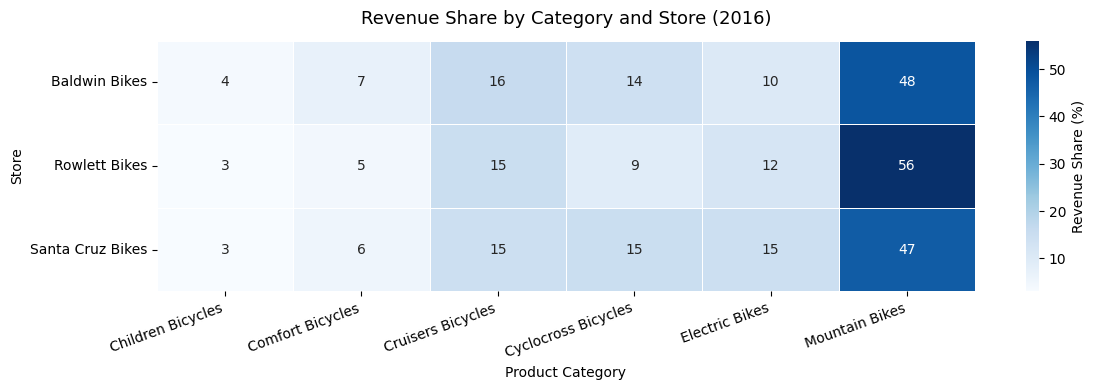

In [125]:
df16 = category_mix_16.DataFrame()

pivot_df16 = df16.pivot_table(
    index='store_name',
    columns='category_name',
    values='revenue_share_pct'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    pivot_df16,
    annot=True,
    fmt='.0f',
    cmap='Blues',        # single colour — showing share, not growth
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Revenue Share (%)'}
)

ax.set_title('Revenue Share by Category and Store (2016)', 
             fontsize=13, pad=12)
ax.set_xlabel('Product Category')
ax.set_ylabel('Store')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

The following heatmap shows how the category mix changed 
across all three stores following the Road Bikes launch in 2017:

In [126]:
%%sql category_mix_17 <<
SELECT 
    s.store_name,
    c.category_name,
    ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric), 0) AS revenue_2017,
    ROUND(
        SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric) /
        SUM(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric)) 
        OVER (PARTITION BY s.store_name) * 100, 1) AS revenue_share_pct
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
JOIN products AS p ON i.product_id = p.product_id
JOIN categories AS c ON p.category_id = c.category_id
WHERE EXTRACT(year FROM order_date::date) = 2017
GROUP BY s.store_name, c.category_name
ORDER BY s.store_name, revenue_share_pct DESC;

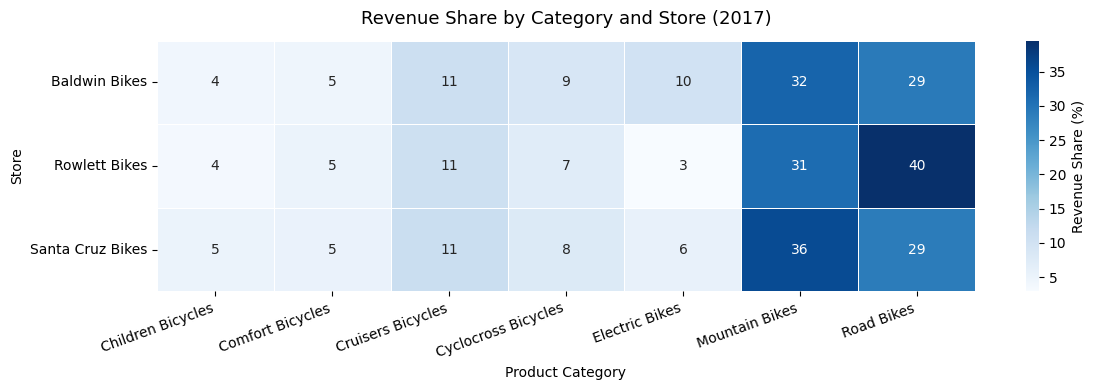

In [127]:
df17 = category_mix_17.DataFrame()

pivot_df17 = df17.pivot_table(
    index='store_name',
    columns='category_name',
    values='revenue_share_pct'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    pivot_df17,
    annot=True,
    fmt='.0f',
    cmap='Blues',        # single colour — showing share, not growth
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Revenue Share (%)'}
)

ax.set_title('Revenue Share by Category and Store (2017)', 
             fontsize=13, pad=12)
ax.set_xlabel('Product Category')
ax.set_ylabel('Store')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Findings:**

**2016 — Homogeneous category mix across all stores:**
- All three stores were heavily concentrated in **Mountain Bikes 
  (47–56% of revenue)**, with similar distribution across 
  remaining categories
- No significant differentiation in product mix between stores, 
  suggesting comparable product strategies prior to 2017

**2017 — Road Bikes adopted across all three stores:**
- Road Bikes became a significant revenue contributor across 
  all stores — **Baldwin Bikes (29%)**, **Rowlett Bikes (40%)** 
  and **Santa Cruz Bikes (29%)**
- Mountain Bikes' revenue share declined across all stores 
  as Road Bikes captured a larger portion of total revenue
- Despite a comparable category mix in 2017, Baldwin Bikes 
  continued to generate significantly higher absolute revenue 
  than Rowlett and Santa Cruz

**Key Question:**

If all three stores adopted Road Bikes with comparable revenue 
share (~29–40%), why did Baldwin grow disproportionately more? 
The following section examines the growth attribution in detail 
to quantify the Road Bikes effect versus organic growth 
across all three stores.

---

## Section 6: Growth Attribution

Having established that all three stores adopted Road Bikes 
in 2017 with comparable revenue share, this section quantifies 
how much of Baldwin's growth was directly driven by the Road 
Bikes launch versus genuine organic growth in existing categories.

The monthly Road Bikes sales at Baldwin are first examined 
to understand the timing and consistency of the new category's 
contribution:

In [128]:
%%sql
SELECT DATE_TRUNC('month', order_date::date)::date AS month,
    COUNT(*) AS orders,
    ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric),0) AS revenue
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
JOIN products AS p ON i.product_id = p.product_id
JOIN categories AS c ON p.category_id = c.category_id
WHERE s.store_name = 'Baldwin Bikes' AND c.category_name = 'Road Bikes'
GROUP BY DATE_TRUNC('month', order_date::date)

month,orders,revenue
2017-01-01,15,47310
2017-02-01,14,35822
2017-03-01,12,30823
2017-04-01,10,26674
2017-05-01,15,46197
2017-06-01,18,52632
2017-07-01,8,26446
2017-08-01,9,29903
2017-09-01,14,52521
2017-10-01,16,45373


To separate the Road Bikes effect from organic growth, 
Baldwin's revenue growth in 2017 was decomposed into two components 
— Road Bikes revenue and growth in existing categories:

In [129]:
%%sql effect_comparison <<
SELECT 
    EXTRACT(year FROM order_date::date)::int AS year,
    ROUND(SUM(CASE WHEN c.category_name != 'Road Bikes' 
              THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric END), 0) AS revenue_excl_road_bikes,
    ROUND(SUM(CASE WHEN c.category_name = 'Road Bikes' 
              THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric END), 0) AS revenue_road_bikes,
    ROUND(SUM(i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric), 0) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
JOIN products AS p ON i.product_id = p.product_id
JOIN categories AS c ON p.category_id = c.category_id
WHERE s.store_name = 'Baldwin Bikes'
    AND EXTRACT(year FROM order_date::date) IN (2016, 2017)
GROUP BY EXTRACT(year FROM order_date::date)
ORDER BY year

In [130]:
ec_df = effect_comparison.DataFrame()

rev_excl_2016 = ec_df[ec_df['year'] == 2016]['revenue_excl_road_bikes'].values[0]
rev_excl_2017 = ec_df[ec_df['year'] == 2017]['revenue_excl_road_bikes'].values[0]
rev_road_2017 = ec_df[ec_df['year'] == 2017]['revenue_road_bikes'].values[0]
total_2016 = ec_df[ec_df['year'] == 2016]['total_revenue'].values[0]
total_2017 = ec_df[ec_df['year'] == 2017]['total_revenue'].values[0]

organic_growth = rev_excl_2017 - rev_excl_2016
road_bike_effect = rev_road_2017 
total_growth = total_2017 - total_2016

print(f"Total revenue 2016:       ${total_2016:,.0f}")
print(f"Total revenue 2017:       ${total_2017:,.0f}")
print(f"Total growth:             ${total_growth:,.0f} ({total_growth/total_2016*100:.1f}%)")
print(f"")
print(f"Road Bikes contribution:  ${road_bike_effect:,.0f} ({road_bike_effect/total_growth*100:.1f}% of growth)")
print(f"Organic growth (ex-Road): ${organic_growth:,.0f} ({organic_growth/total_growth*100:.1f}% of growth)")

Total revenue 2016:       $1,590,599
Total revenue 2017:       $2,479,688
Total growth:             $889,089 (55.9%)

Road Bikes contribution:  $724,018 (81.4% of growth)
Organic growth (ex-Road): $165,071 (18.6% of growth)


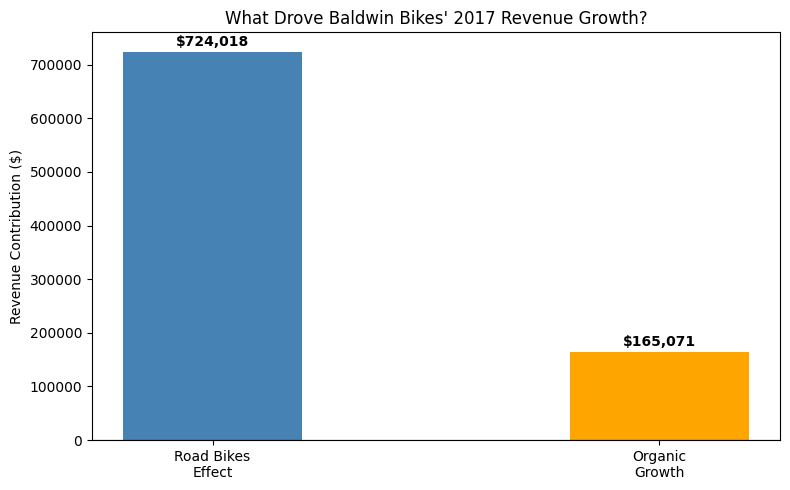

In [131]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Road Bikes\nEffect', 'Organic\nGrowth']
values = [road_bike_effect, organic_growth]
colors = ['steelblue', 'orange']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, values, color=colors, width=0.4)

# Add value labels on bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.axhline(y=0, color='black', linewidth=0.8)
plt.title("What Drove Baldwin Bikes' 2017 Revenue Growth?")
plt.ylabel('Revenue Contribution ($)')
plt.tight_layout()
plt.show()

To determine whether the same pattern holds across all three 
stores, the Road Bikes revenue contribution and organic growth 
were compared chain-wide:

In [132]:
%%sql 
SELECT 
    s.store_name,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2016 
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS total_2016,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017 
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS total_2017,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017
        AND c.category_name = 'Road Bikes'
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS road_bikes_2017,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017
        AND c.category_name != 'Road Bikes'
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END) -
    SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2016
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS organic_growth,
    ROUND(
        SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017 
            THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
            ELSE 0 END) -
        SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2016 
            THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
            ELSE 0 END), 0) AS total_growth
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
JOIN products AS p ON i.product_id = p.product_id
JOIN categories AS c ON p.category_id = c.category_id
GROUP BY s.store_name
ORDER BY total_growth DESC;

store_name,total_2016,total_2017,road_bikes_2017,organic_growth,total_growth
Baldwin Bikes,1590599,2479688,724018,165071,889090
Rowlett Bikes,271286,404612,160005,-26680,133325
Santa Cruz Bikes,565494,562908,162055,-164640,-2585


In [136]:
%%sql road_bike_effect <<
SELECT 
    s.store_name,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2016 
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS total_2016,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017 
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS total_2017,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017
        AND c.category_name = 'Road Bikes'
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS road_bikes_2017,
    ROUND(SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017
        AND c.category_name != 'Road Bikes'
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END) -
    SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2016
        THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
        ELSE 0 END), 0) AS organic_growth,
    ROUND(
        SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2017 
            THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
            ELSE 0 END) -
        SUM(CASE WHEN EXTRACT(year FROM order_date::date) = 2016 
            THEN i.list_price::numeric * (1-i.discount)::numeric * i.quantity::numeric 
            ELSE 0 END), 0) AS total_growth
FROM orders AS o
JOIN order_items AS i ON o.order_id = i.order_id
JOIN stores AS s ON o.store_id = s.store_id
JOIN products AS p ON i.product_id = p.product_id
JOIN categories AS c ON p.category_id = c.category_id
GROUP BY s.store_name
ORDER BY total_growth DESC;

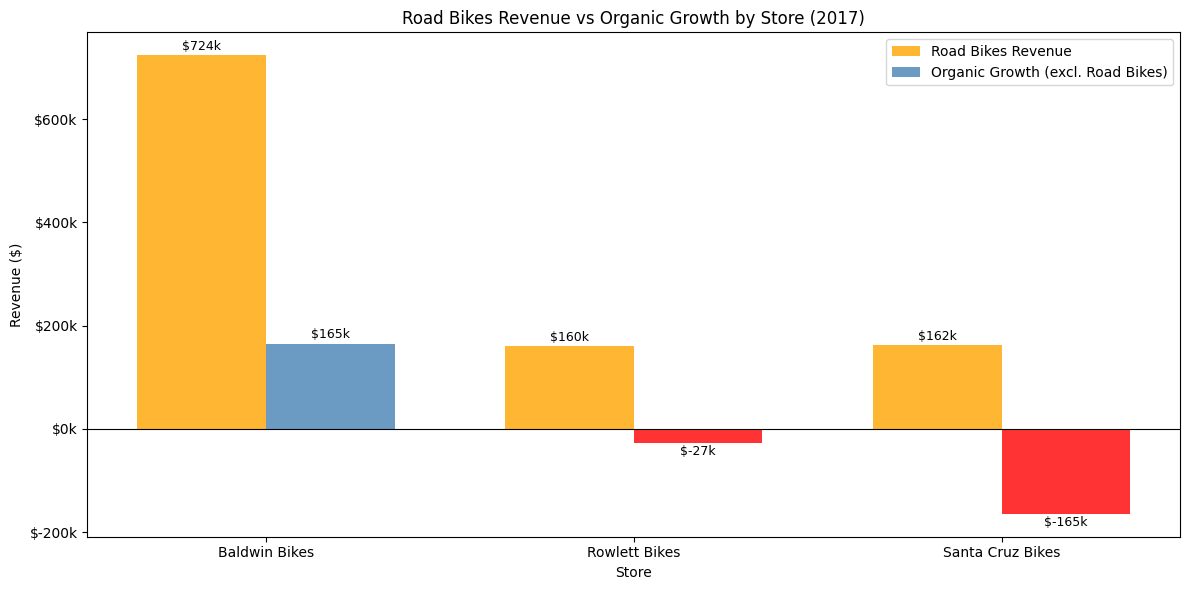

In [137]:
df = road_bike_effect.DataFrame()
df['organic_growth'] = df['organic_growth'].astype(float)
df['road_bikes_2017'] = df['road_bikes_2017'].astype(float)
df['total_growth'] = df['total_growth'].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df['store_name']))
width = 0.35

bars1 = ax.bar(x - width/2, df['road_bikes_2017'], width,
               label='Road Bikes Revenue', color='orange', alpha=0.8)
bars2 = ax.bar(x + width/2, df['organic_growth'], width,
               label='Organic Growth (excl. Road Bikes)', 
               color=df['organic_growth'].apply(
                   lambda x: 'steelblue' if x >= 0 else 'red'), 
               alpha=0.8)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.,
            height + 5000,
            f'${height/1000:.0f}k',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = 5000 if height >= 0 else -5000
    ax.text(bar.get_x() + bar.get_width()/2.,
            height + offset,
            f'${height/1000:.0f}k',
            ha='center', va=va, fontsize=9)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df['store_name'])
ax.set_xlabel('Store')
ax.set_ylabel('Revenue ($)')
ax.set_title('Road Bikes Revenue vs Organic Growth by Store (2017)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

**Findings:**

**Baldwin Bikes — Growth Attribution:**
- Road Bikes accounted for **81.4% of Baldwin's total 2017 growth** 
  (USD 724k out of USD 889k total growth)
- Existing categories contributed a further **USD 165k in organic 
  growth** — confirming Baldwin's underlying business was already 
  on a positive trajectory before Road Bikes launched

**Cross-Store Comparison:**

All three stores generated comparable Road Bikes revenue in 2017, 
however their organic growth trajectories diverged significantly:

| Store | Road Bikes Revenue | Organic Growth | Total Growth |
|-------|-------------------|----------------|--------------|
| Baldwin Bikes | USD 724k | +USD 165k | +USD 889k |
| Rowlett Bikes | USD 160k | -USD 27k | +USD 133k |
| Santa Cruz Bikes | USD 162k | -USD 165k | -USD 3k |

- **Baldwin Bikes** — Road Bikes contributed USD 724k while 
  existing categories grew by an additional USD 165k, indicating 
  strong overall business performance
- **Rowlett Bikes** — Road Bikes generated USD 160k but existing 
  category revenue declined by USD 27k, suggesting Road Bikes 
  partially cannibalised other categories
- **Santa Cruz Bikes** — Despite generating USD 162k in Road Bikes 
  revenue, existing categories declined by USD 165k — effectively 
  resulting in flat overall growth (-USD 3k)

**Key Insight:**

Road Bikes alone does not explain Baldwin's dominance. Baldwin 
was the **only store where existing categories also grew** 
alongside the Road Bikes launch, suggesting a structural 
advantage, likely related to store location, local market 
size or customer demographics, that amplifies the impact 
of new product launches more effectively than at other stores.

Conclusively identifying this structural advantage would 
require external data, such as customer footfall, local 
demographics and competitor presence, which falls outside 
the scope of this dataset.

## Conclusion & Recommendations

### Summary of Findings

This analysis examined sales performance across three bike retail 
stores — Baldwin Bikes, Rowlett Bikes and Santa Cruz Bikes — 
over the period 2016 to 2017.

**1. Baldwin Bikes consistently dominates chain-wide revenue**

Baldwin generated 3–4x higher revenue than Rowlett and Santa Cruz 
throughout the entire analysis period. This dominance was sustained 
across both years and across all product categories, suggesting 
a structural advantage rather than a temporary effect.

**2. Both average price and sales volume increased in 2017**

Baldwin's revenue growth was driven by a simultaneous increase 
in average selling price (ard 30%) and total sales volume (ard 20%), 
indicating an increase in overall store popularity.

**3. Road Bikes launch was the primary growth driver**

The introduction of Road Bikes as a new category in 2017 
accounted for **81.4% of Baldwin's total revenue growth**, 
generating approximately USD 724k in its first year. All three 
stores adopted Road Bikes in 2017, generating comparable 
Road Bikes revenue (USD 160k at Rowlett and Santa Cruz).

**4. Road Bikes adoption had divergent effects across stores**

Despite similar Road Bikes revenue across stores, the impact 
on overall performance diverged significantly:

| Store | Road Bikes Revenue | Organic Growth | Total Growth |
|-------|-------------------|----------------|--------------|
| Baldwin Bikes | \$724k | +\$165k | +\$889k |
| Rowlett Bikes | \$160k | -\$27k | +\$133k |
| Santa Cruz Bikes | \$162k | -\$165k | -\$3k |

Baldwin was the **only store where existing category revenue 
also grew** alongside Road Bikes. Rowlett and Santa Cruz both 
experienced declines in non-Road Bikes revenue, suggesting 
Road Bikes partially cannibalised their existing categories 
or that underlying demand in those locations is weakening.

**5. Baldwin's structural advantage remains unexplained**

The data consistently points to Baldwin benefiting from a 
structural advantage, likely related to store location, 
local market size or customer demographics, that amplifies 
the impact of new product launches more effectively than 
at other stores. Conclusively identifying this advantage 
would require external data beyond the scope of this dataset.

---

### Business Recommendations

**1. Investigate Baldwin's structural advantage**

Baldwin consistently outperforms other stores even when 
controlling for product mix. A deeper investigation into 
store location, local demographics, customer acquisition 
channels and competitor presence is recommended to identify 
the root cause of this advantage and assess whether 
Baldwin's model can be replicated at Rowlett and Santa Cruz.

**2. Address organic revenue decline at Rowlett and Santa Cruz**

Both Rowlett and Santa Cruz experienced declining non-Road 
Bikes revenue in 2017 despite the chain-wide Road Bikes launch. 
A targeted category-level pricing and promotions strategy 
should be considered to stabilise and recover existing 
revenue streams at these locations.

**3. Monitor and invest in Children bicycles**

Among all existing categories, Children Bicycles recorded the 
highest revenue growth rate in 2017 across all three stores — 
Baldwin Bikes (66.3%), Rowlett Bikes (77.6%) and Santa Cruz 
Bikes (67.2%). This consistent growth pattern across all 
locations suggests a genuine demand trend rather than a 
store-specific effect.

Proactive investment in Children Bicycles inventory across 
all three stores is recommended to capitalise on this momentum. 
Further investigation into the customer demographic driving 
this growth, such as age group and purchasing occasion, 
would help inform targeted marketing and inventory decisions.

**4. Expand the analysis with external data**

The current analysis is limited to internal transaction data. 
Incorporating external sources, such as local market size, 
competitor presence, customer demographics and foot traffic 
data, would enable more robust conclusions about the 
underlying drivers of performance differences across stores 
and strengthen the basis for strategic decision making.

---

### Limitations

- Analysis is scoped to **2016–2017** due to incomplete 2018 data
- Internal transaction data only — no external market context available
- The root cause of Baldwin's structural advantage cannot be 
  conclusively determined without customer footfall, demographic 
  and competitor data
- Revenue figures reflect list price adjusted for discount as 
  actual margin data was not available for profitability analysis